# Model Building For Marketing Objective
## About Data

The dataset consists of total 42 columns i.e. attributes including 'label' for income (whether a person earns **more than $50k** or **$50k or less**)


This notebook consists of two separate portions:

1. The **classification model** that predicts income groups based on labels. 
2. The **segmentation model** that groups people into meaningful clusters for marketing.

## Classification Model

In [ ]:
# Reading the data
from pathlib import Path
import pandas as pd

base_dir = Path.cwd()
columns_path = base_dir / "census-bureau.columns"
data_path = base_dir / "census-bureau.data"

with open(columns_path, "r", encoding="utf-8") as f:
    census_columns = [line.strip() for line in f if line.strip()]

census_df = pd.read_csv(
    data_path,
    header=None,
    names=census_columns,
    skipinitialspace=True,
    na_values=["?"],
)

census_df.head(2)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.


In [5]:
census_columns

['age',
 'class of worker',
 'detailed industry recode',
 'detailed occupation recode',
 'education',
 'wage per hour',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'weight',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'num persons worked for employer',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 'own business or self employed',
 "fill inc questionnaire for veteran's admin"

In [6]:
# Basic inspection
print("Shape:", census_df.shape)
print("\nLabel distribution:")
print(census_df["label"].value_counts(dropna=False))
print("\nMissing values per column (top 10):")
print(census_df.isna().sum().sort_values(ascending=False).head(10))

Shape: (199523, 42)

Label distribution:
label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

Missing values per column (top 10):
migration prev res in sunbelt     99696
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
age                                   0
dtype: int64


In [24]:
census_df['migration prev res in sunbelt'].unique(),census_df['migration code-change in msa'].unique(),census_df['migration code-change in reg'].unique(),census_df['state of previous residence'].unique()


(array([nan, 'Yes', 'Not in universe', 'No'], dtype=object),
 array([nan, 'MSA to MSA', 'Nonmover', 'NonMSA to nonMSA',
        'Not in universe', 'Not identifiable', 'Abroad to MSA',
        'MSA to nonMSA', 'Abroad to nonMSA', 'NonMSA to MSA'], dtype=object),
 array([nan, 'Same county', 'Nonmover', 'Different region',
        'Different county same state', 'Not in universe',
        'Different division same region', 'Abroad',
        'Different state same division'], dtype=object),
 array(['Not in universe', 'Arkansas', 'Utah', 'Michigan', 'Minnesota',
        'Alaska', 'Kansas', 'Indiana', nan, 'Massachusetts', 'New Mexico',
        'Nevada', 'Tennessee', 'Colorado', 'Abroad', 'Kentucky',
        'California', 'Arizona', 'North Carolina', 'Connecticut',
        'Florida', 'Vermont', 'Maryland', 'Oklahoma', 'Oregon', 'Ohio',
        'South Carolina', 'Texas', 'Montana', 'Wyoming', 'Georgia',
        'Pennsylvania', 'Iowa', 'New Hampshire', 'Missouri', 'Alabama',
        'North Dakota

In [29]:
census_df['full or part time employment stat'].unique(),census_df['detailed household summary in household'].unique(),census_df['detailed household and family stat'].unique()

(array(['Not in labor force', 'Children or Armed Forces',
        'Full-time schedules', 'Unemployed full-time',
        'Unemployed part- time', 'PT for non-econ reasons usually FT',
        'PT for econ reasons usually PT', 'PT for econ reasons usually FT'],
       dtype=object),
 array(['Other relative of householder', 'Householder',
        'Child 18 or older', 'Child under 18 never married',
        'Spouse of householder', 'Nonrelative of householder',
        'Group Quarters- Secondary individual',
        'Child under 18 ever married'], dtype=object),
 array(['Other Rel 18+ ever marr not in subfamily', 'Householder',
        'Child 18+ never marr Not in a subfamily',
        'Child <18 never marr not in subfamily', 'Spouse of householder',
        'Secondary individual',
        'Other Rel 18+ never marr not in subfamily',
        'Nonfamily householder',
        'Grandchild <18 never marr not in subfamily',
        'Grandchild <18 never marr child of subfamily RP',
        'Ch

In [49]:
census_df["fill inc questionnaire for veteran's admin"].unique()

array(['Not in universe', 'No', 'Yes'], dtype=object)

In [15]:
#Given: The weight indicates the relative distribution of people in the general population that each record represents due to stratified sampling.
census_df['weight']
# Design Decision: Going to ingnore for now. Weights can be incorporated in future work for population-level calibration
print(census_df['weight'].value_counts())

weight
753.23     32
1787.34    32
1601.40    32
1191.21    32
1317.51    31
           ..
5239.18     1
2755.99     1
652.97      1
2339.53     1
2727.72     1
Name: count, Length: 99800, dtype: int64


<ipython-input-48-6fefd16baf72>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-48-6fefd16baf72>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-48-6fefd16baf72>:10: UserWarning: 

`distplot` is a deprecated function

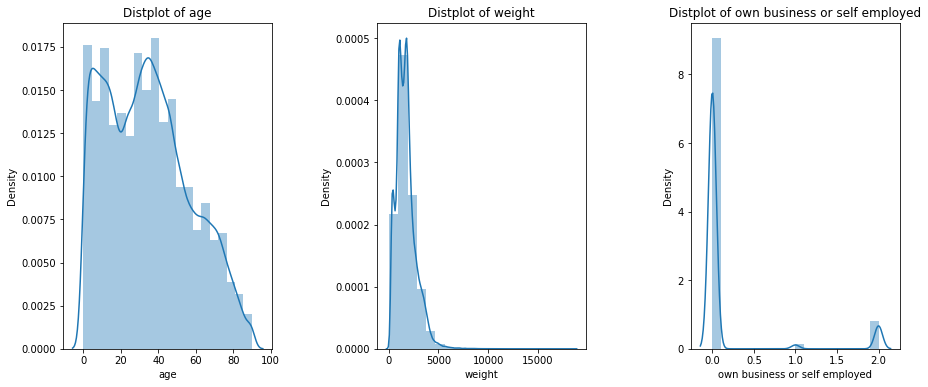

In [48]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.figure(1,figsize=(15,6))
n=0
for x in ['age', 'weight', 'own business or self employed']:
    n += 1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(census_df[x], bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

<ipython-input-16-9aea451585f3>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-16-9aea451585f3>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-16-9aea451585f3>:7: UserWarning: 

`distplot` is a deprecated function an

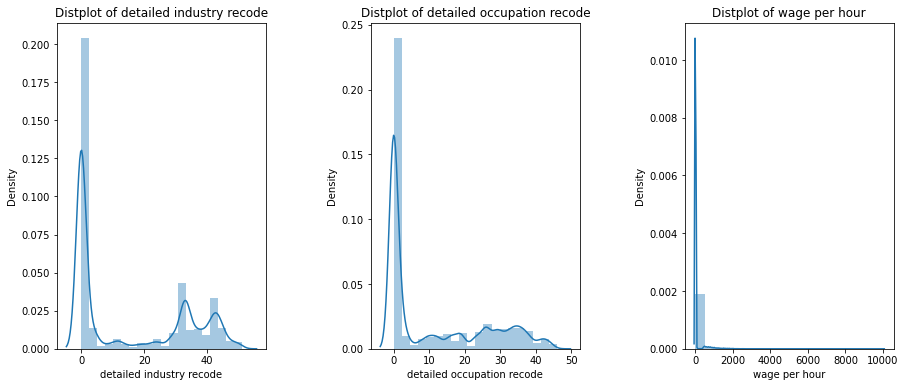

In [16]:
plt.figure(1,figsize=(15,6))
n=0
for x in ['detailed industry recode', 'detailed occupation recode', 'wage per hour']:
    n += 1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(census_df[x], bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

<ipython-input-17-406346839361>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-17-406346839361>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-17-406346839361>:7: UserWarning: 

`distplot` is a deprecated function an

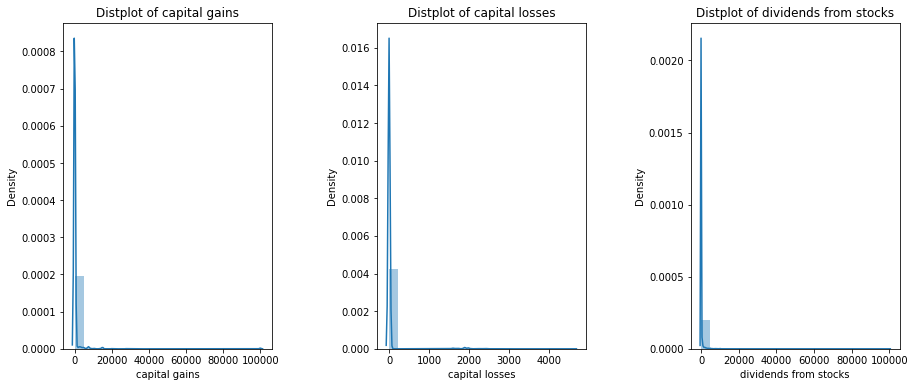

In [17]:
plt.figure(1,figsize=(15,6))
n=0
for x in ['capital gains', 'capital losses', 'dividends from stocks']:
    n += 1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(census_df[x], bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

<ipython-input-25-9b4b5f938db8>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)


<ipython-input-25-9b4b5f938db8>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-25-9b4b5f938db8>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)


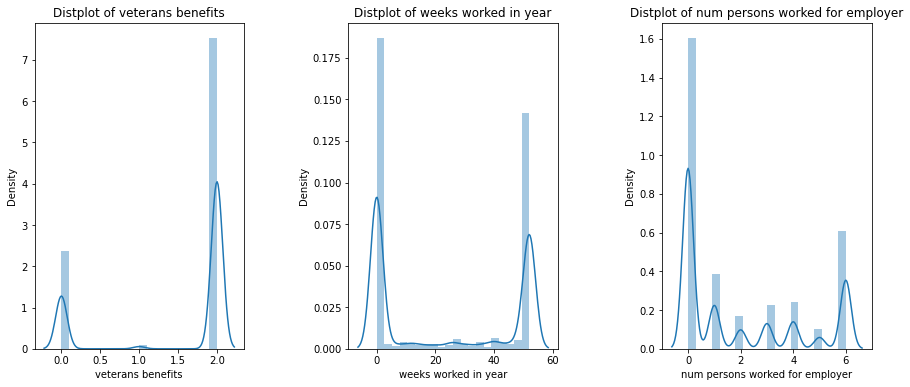

In [25]:
plt.figure(1,figsize=(15,6))
n=0
for x in ['veterans benefits', 'weeks worked in year', 'num persons worked for employer']:
    n += 1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(census_df[x], bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

In [9]:
census_df.dtypes

age                                             int64
class of worker                                object
detailed industry recode                        int64
detailed occupation recode                      int64
education                                      object
wage per hour                                   int64
enroll in edu inst last wk                     object
marital stat                                   object
major industry code                            object
major occupation code                          object
race                                           object
hispanic origin                                object
sex                                            object
member of a labor union                        object
reason for unemployment                        object
full or part time employment stat              object
capital gains                                   int64
capital losses                                  int64
dividends from stocks       

In [8]:
census_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0
detailed industry recode,199523.0,15.352320,18.067129,0.00,0.000,0.00,33.00,51.0
detailed occupation recode,199523.0,11.306556,14.454204,0.00,0.000,0.00,26.00,46.0
wage per hour,199523.0,55.426908,274.896454,0.00,0.000,0.00,0.00,9999.0
capital gains,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0
capital losses,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0
dividends from stocks,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0
weight,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3
num persons worked for employer,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0
own business or self employed,199523.0,0.175438,0.553694,0.00,0.000,0.00,0.00,2.0


In [52]:
num_cols = census_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = census_df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c !='label']
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'weight', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year']
Categorical columns: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'cit

In [55]:
census_df['label'].value_counts(), census_df['label'].value_counts(normalize=True)

(label
 - 50000.    187141
 50000+.      12382
 Name: count, dtype: int64,
 label
 - 50000.    0.937942
 50000+.     0.062058
 Name: proportion, dtype: float64)

In [62]:
#Missing Values
missing = census_df.isna().sum().sort_values(ascending=False).head(10)
missing_pct = (census_df.isna().mean() * 100).sort_values(ascending=False).head(10)
pd.DataFrame({"missing": missing, "missing_pct": missing_pct})

,missing,missing_pct
migration prev res in sunbelt,99696,49.967172
migration code-change in msa,99696,49.967172
migration code-change in reg,99696,49.967172
migration code-move within reg,99696,49.967172
country of birth father,6713,3.364524
country of birth mother,6119,3.066814
country of birth self,3393,1.700556
hispanic origin,874,0.438045
state of previous residence,708,0.354846
age,0,0.000000


In [63]:
# Cardinality for categoricals
census_df[cat_cols].nunique().sort_values(ascending=False)

state of previous residence                   50
country of birth father                       42
country of birth self                         42
country of birth mother                       42
detailed household and family stat            38
major industry code                           24
education                                     17
major occupation code                         15
hispanic origin                                9
migration code-change in msa                   9
migration code-move within reg                 9
class of worker                                9
migration code-change in reg                   8
detailed household summary in household        8
full or part time employment stat              8
marital stat                                   7
reason for unemployment                        6
tax filer stat                                 6
region of previous residence                   6
race                                           5
citizenship         

In [70]:
for col in ['migration prev res in sunbelt', 'migration code-change in msa', 'migration code-move within reg','state of previous residence']:
    print(census_df[col].value_counts(dropna=False).head(10))
    print("*********")

migration prev res in sunbelt
NaN                99696
Not in universe    84054
No                  9987
Yes                 5786
Name: count, dtype: int64
*********
migration code-change in msa
NaN                 99696
Nonmover            82538
MSA to MSA          10601
NonMSA to nonMSA     2811
Not in universe      1516
MSA to nonMSA         790
NonMSA to MSA         615
Abroad to MSA         453
Not identifiable      430
Abroad to nonMSA       73
Name: count, dtype: int64
*********
migration code-move within reg
NaN                             99696
Nonmover                        82538
Same county                      9812
Different county same state      2797
Not in universe                  1516
Different state in South          973
Different state in West           679
Different state in Midwest        551
Abroad                            530
Different state in Northeast      431
Name: count, dtype: int64
*********
state of previous residence
Not in universe    183750
Californ

<function matplotlib.pyplot.show(close=None, block=None)>

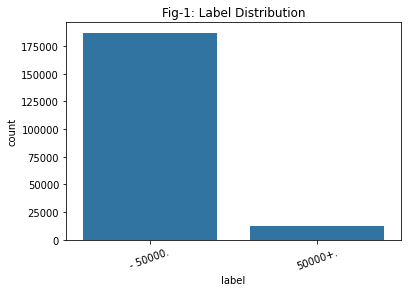

In [74]:
sns.countplot(data=census_df, x = "label")
plt.xticks(rotation=20)
plt.title("Fig-1: Label Distribution")
plt.show

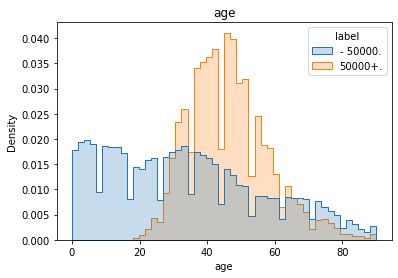

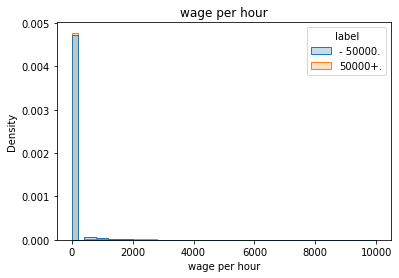

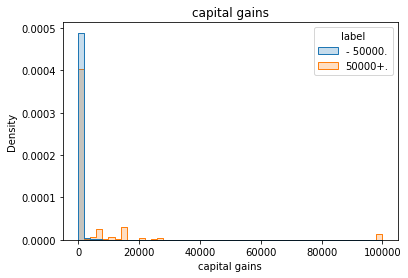

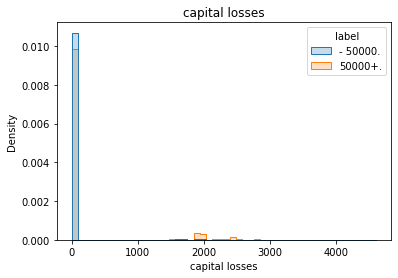

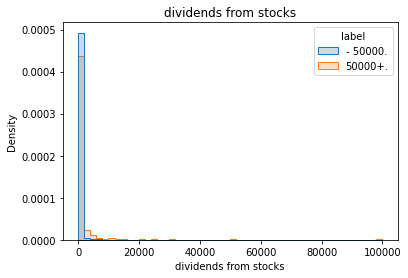

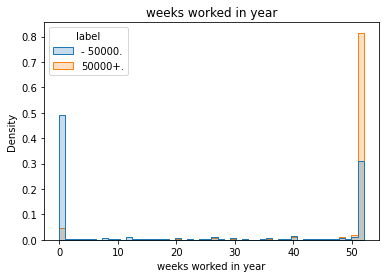

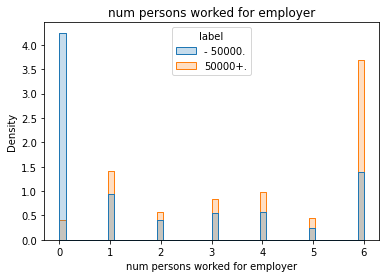

In [78]:
# Numeric distributions
for col in ["age", "wage per hour", "capital gains", "capital losses",
            "dividends from stocks", "weeks worked in year", "num persons worked for employer"]:
    plt.figure()
    sns.histplot(data=census_df, x=col, hue="label", bins=50, element="step", stat="density", common_norm=False)
    plt.title(col)
    plt.show()

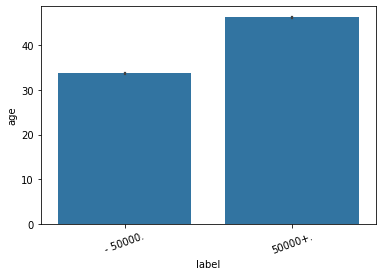

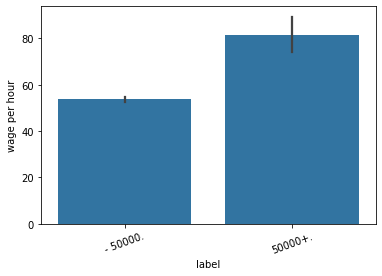

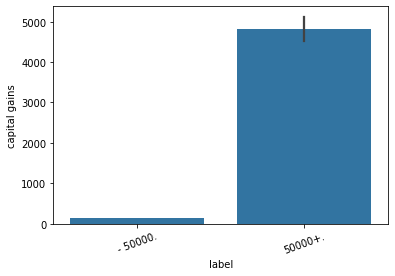

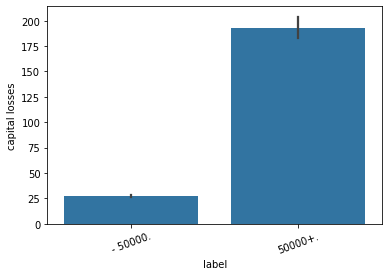

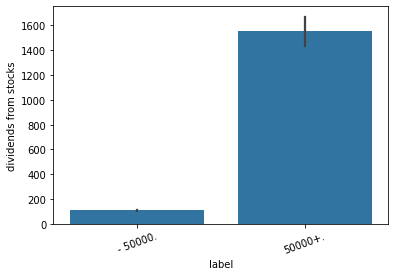

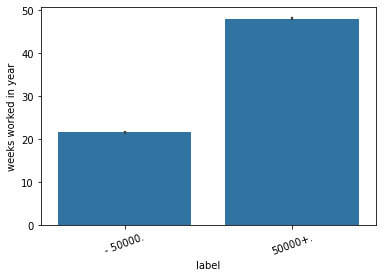

In [80]:
# Boxplots against target
for col in ["age", "wage per hour", "capital gains", "capital losses",
            "dividends from stocks", "weeks worked in year"]:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=census_df, x="label", y=col)
    plt.xticks(rotation=20)
    plt.show()

In [83]:
# Categorical vs target: top categories
for col in ["education", "marital stat", "sex", "race", "class of worker",
            "major occupation code", "major industry code", "citizenship"]:
    tmp = (
        census_df.groupby(col)["label"]
        .apply(lambda s: (s == "50000+").mean())
        .sort_values(ascending=False)
        .head(15)
    )
    print("\n", col)
    print(tmp)


 education
education
10th grade                                0.0
11th grade                                0.0
12th grade no diploma                     0.0
1st 2nd 3rd or 4th grade                  0.0
5th or 6th grade                          0.0
7th and 8th grade                         0.0
9th grade                                 0.0
Associates degree-academic program        0.0
Associates degree-occup /vocational       0.0
Bachelors degree(BA AB BS)                0.0
Children                                  0.0
Doctorate degree(PhD EdD)                 0.0
High school graduate                      0.0
Less than 1st grade                       0.0
Masters degree(MA MS MEng MEd MSW MBA)    0.0
Name: label, dtype: float64

 marital stat
marital stat
Divorced                           0.0
Married-A F spouse present         0.0
Married-civilian spouse present    0.0
Married-spouse absent              0.0
Never married                      0.0
Separated                          0.

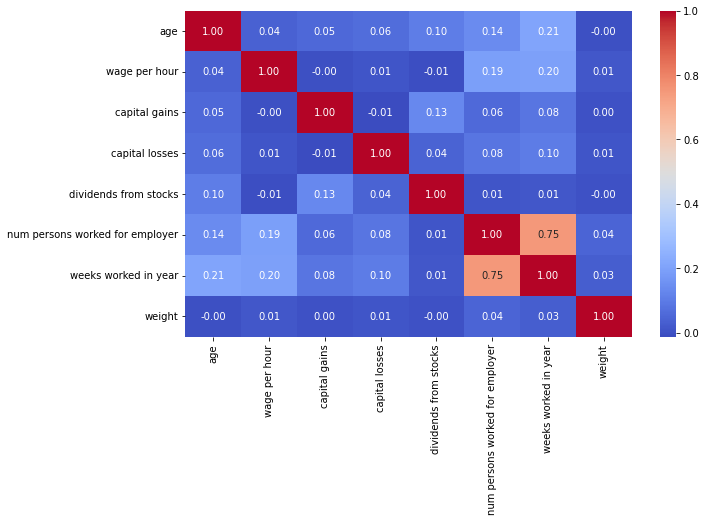

In [84]:
# Correlation among true numeric columns
true_num_cols = ["age", "wage per hour", "capital gains", "capital losses",
                 "dividends from stocks", "num persons worked for employer",
                 "weeks worked in year", "weight"]
plt.figure(figsize=(10, 6))
sns.heatmap(census_df[true_num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [127]:
# Income rate by category
def income_rate_by(col):
    return (
        census_df.groupby(col)["label"]
        .apply(lambda s: (s == "50000+.").mean())
        .sort_values(ascending=False)
    )

print(income_rate_by("education"))
print(income_rate_by("marital stat"))
print(income_rate_by("sex"))
print(income_rate_by("class of worker"))

education
Prof school degree (MD DDS DVM LLB JD)    0.540435
Doctorate degree(PhD EdD)                 0.520190
Masters degree(MA MS MEng MEd MSW MBA)    0.311573
Bachelors degree(BA AB BS)                0.197080
Associates degree-academic program        0.094430
Associates degree-occup /vocational       0.077081
Some college but no degree                0.064234
High school graduate                      0.038817
12th grade no diploma                     0.015992
11th grade                                0.010180
7th and 8th grade                         0.008992
10th grade                                0.008204
1st 2nd 3rd or 4th grade                  0.007226
5th or 6th grade                          0.006713
9th grade                                 0.006100
Less than 1st grade                       0.001221
Children                                  0.000000
Name: label, dtype: float64
marital stat
Married-civilian spouse present    0.113984
Divorced                           0.0

In [142]:
target = census_df['label']
X = census_df.drop(columns=['label'])
census_df.shape, X.shape

((199523, 42), (199523, 41))

In [115]:
census_df['country of birth father'].isna().sum()

np.int64(6713)

In [143]:
# Check remaining missingness
# 'Not i universe' and rest Nan values shoudl be mapped to single nan value, shown later
X.isna().sum().sort_values(ascending=False).head(10)

migration prev res in sunbelt     99696
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
major industry code                   0
dtype: int64

In [122]:
census_df['detailed industry recode'].unique(), census_df['wage per hour'].unique()

(array([ 0,  4, 40, 34, 43, 37, 24, 39, 12, 35, 45,  3, 19, 29, 32, 48, 33,
        23, 44, 36, 31, 30, 41,  5, 11,  9, 42,  6, 18, 50,  2,  1, 26, 47,
        16, 14, 22, 17,  7,  8, 25, 46, 27, 15, 13, 49, 38, 21, 28, 20, 51,
        10]),
 array([   0, 1200,  876, ..., 3156, 2188, 1092], shape=(1240,)))

In [125]:
for col in num_cols:
    print(col)
    print(census_df[col].unique())

age
[73 58 18  9 10 48 42 28 47 34  8 32 51 46 26 13 39 16 35 12 27 56 55  2
  1 37  4 63 25 81 11 30  7 66 84 52  5 36 72 61 41 90 49  6  0 33 57 50
 24 17 53 40 54 22 29 85 38 76 21 31 74 19 15  3 43 68 71 45 62 23 69 75
 44 59 60 64 65 70 67 78 20 14 83 86 89 77 79 82 80 87 88]
detailed industry recode
[ 0  4 40 34 43 37 24 39 12 35 45  3 19 29 32 48 33 23 44 36 31 30 41  5
 11  9 42  6 18 50  2  1 26 47 16 14 22 17  7  8 25 46 27 15 13 49 38 21
 28 20 51 10]
detailed occupation recode
[ 0 34 10  3 40 26 37 31 12 36 41 22  2 35 25 23 42  8 19 29 27 16 33 13
 18  9 17 39 32 11 30 38 20  7 21 44 24 43 28  4  1  6 45 14  5 15 46]
wage per hour
[   0 1200  876 ... 3156 2188 1092]
capital gains
[    0  5178   991  2829  3464  5556  7298 15024  1831  3137 10605 20051
  2538  3908  2407  2050  3103  1086  7688  5013  4386  2414 99999 13550
  2174  4650  4064   914  2354  4787  2009  2597  1055  6097  2635  2105
  3325  6767  2228  2062  3942 27828  9562  2176  7262  2202  2290  1173
  8614

In [144]:
census_df.isna().sum().sort_values(ascending=False).head(10)

migration prev res in sunbelt     99696
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
age                                   0
dtype: int64

In [145]:
census_df["migration prev res in sunbelt"].value_counts(dropna=False)

migration prev res in sunbelt
NaN                99696
Not in universe    84054
No                  9987
Yes                 5786
Name: count, dtype: int64

In [146]:
import numpy as np

missing_tokens = ["?", "NaN", "Unknown", "None"]
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].replace(missing_tokens, np.nan)

In [ ]:
X.isna().sum().sort_values(ascending=False).head(10)
# The change here in values shows that significant values are 'Not in universe',
# Treat "Not in universe" as one of the cat value as could be high signal for some questions.
# Specifically important to categorical columns
# Deciding to drop migration related columnd due to its heavy missing value count and 

migration prev res in sunbelt     99696
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
major industry code                   0
dtype: int64

In [149]:
drop_cols = [
    "label",
    "migration prev res in sunbelt",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "year"
]

In [150]:
continuous_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weight",
    "weeks worked in year",
]

categorical_int_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "own business or self employed",
    "veterans benefits",
]

categorical_obj_cols = X.select_dtypes(include="object").columns.tolist()

In [153]:
categorical_cols = categorical_int_cols + categorical_obj_cols

In [160]:
print(income_rate_by("education"))
print(income_rate_by("marital stat"))
print(income_rate_by("class of worker"))
print(income_rate_by("major occupation code"))
print(income_rate_by("sex"))

education
Prof school degree (MD DDS DVM LLB JD)    0.540435
Doctorate degree(PhD EdD)                 0.520190
Masters degree(MA MS MEng MEd MSW MBA)    0.311573
Bachelors degree(BA AB BS)                0.197080
Associates degree-academic program        0.094430
Associates degree-occup /vocational       0.077081
Some college but no degree                0.064234
High school graduate                      0.038817
12th grade no diploma                     0.015992
11th grade                                0.010180
7th and 8th grade                         0.008992
10th grade                                0.008204
1st 2nd 3rd or 4th grade                  0.007226
5th or 6th grade                          0.006713
9th grade                                 0.006100
Less than 1st grade                       0.001221
Children                                  0.000000
Name: label, dtype: float64
marital stat
Married-civilian spouse present    0.113984
Divorced                           0.0

- Data Summary 
    - Continuous / Numerical Attributes
        - age, wage per hour, capital gains, capital losses, dividends from stocks, weeks worked in year, weight
    - Encoded Categorical Attributes
        - cat_cols are categorical columns, needs to drop a lot of them as below. 
- Questions:    
    - Should drop 'citizenship' too? 
- Higher education correlates strongly with higher income. 
    - Prof school degree (MD DDS DVM LLB JD): 54%
    - Doctorate degree(PhD EdD): 52% etc.
- Class of worker: self employed have and federal worker have okish correlation with income. 
    - Self-employed-incorporated: 34%
    - Federal government: 20%
- major occupation code: marginal and professional occupation are strongly associated with >50k income.
    - Executive admin and managerial: 28%
    - Professional specialty: 24%
- Sex: Possible showcasing the bias. Shows gender imbalance in high-incomes. 
    - Male: 10%
    - Female: 2.5%

In [ ]:
X = census_df.drop(columns=[
    "label",
    "migration prev res in sunbelt",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
])
census_df["label"] = (
    census_df["label"] == "50000+."
).astype(int)
y = census_df["label"] # now 0 or 1

In [165]:
continuous_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weight",
    "weeks worked in year",
]

categorical_int_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "own business or self employed",
    "veterans benefits",
]

categorical_obj_cols = [
    col for col in X.select_dtypes(include="object").columns
]

categorical_cols = categorical_int_cols + categorical_obj_cols

In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((159618, 37), (39905, 37), (159618,), (39905,))

In [185]:
X_train.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'live in this house 1 year ago', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed',
       'fill inc questionnaire for veteran's admin', 'veterans benefits',
       'weeks worked in year', 'year'],
 

### Preprocessing

- numeric: median imputation + scaling
- categorical: most frequent imputation and one-hot encoding

In [172]:
#Preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, continuous_cols),
    ("cat", categorical_transformer, categorical_cols)
])
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])


In [173]:
#Train the modle
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [178]:
#Evaluate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(roc_curve(y_true=y_test,y_score=y_prob))


              precision    recall  f1-score   support

           0       0.99      0.85      0.92     37429
           1       0.29      0.90      0.43      2476

    accuracy                           0.85     39905
   macro avg       0.64      0.87      0.67     39905
weighted avg       0.95      0.85      0.89     39905

[[31865  5564]
 [  253  2223]]
ROC AUC: 0.946329638828082
(array([0.        , 0.        , 0.        , ..., 0.99684736, 0.9969008 ,
       1.        ], shape=(3087,)), array([0.00000000e+00, 4.03877221e-04, 4.44264943e-03, ...,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00], shape=(3087,)), array([           inf, 1.00000000e+00, 9.99999999e-01, ...,
       7.09944776e-06, 7.08329709e-06, 1.99346865e-06], shape=(3087,)))


In [177]:
#Imbalanced
clf_im = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000))
])
clf_im.fit(X_train, y_train)
y_pred_im = clf_im.predict(X_test)
y_prob_im = clf_im.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_im))
print(confusion_matrix(y_test, y_pred_im))
print("ROC AUC:", roc_auc_score(y_test, y_prob_im))
print(roc_curve(y_true=y_test,y_score=y_prob_im))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     37429
           1       0.73      0.38      0.50      2476

    accuracy                           0.95     39905
   macro avg       0.85      0.68      0.74     39905
weighted avg       0.95      0.95      0.95     39905

[[37086   343]
 [ 1544   932]]
ROC AUC: 0.946249368378713
(array([0.        , 0.        , 0.        , ..., 0.99698095, 0.99703439,
       1.        ], shape=(3100,)), array([0.00000000e+00, 4.03877221e-04, 8.07754443e-03, ...,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00], shape=(3100,)), array([           inf, 1.00000000e+00, 9.99989958e-01, ...,
       3.94255710e-06, 3.93865266e-06, 1.37929442e-06], shape=(3100,)))


- balanced vs imbalance recall difference is clearly visible. 
    - Imbalanced Recall (0: 0.99, 1: 0.38)
    - Balanced Recall (0: 0.85, 1: 0.90)
- balanced vs imbalance precision difference is clearly visible. 
    - Imbalanced precision (0: 0.96, 1: 0.73)
    - Balanced precision (0: 0.99, 1: 0.29)

- If the retail company wants:
    - broader marketing reach for premium products
    - fewer missed high-income customers
        -  then higher recall may be preferable.

- But if marketing campaigns are expensive then low precision becomes costly because many low-income customers are incorrectly targeted.

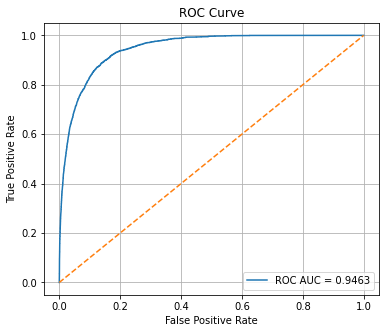

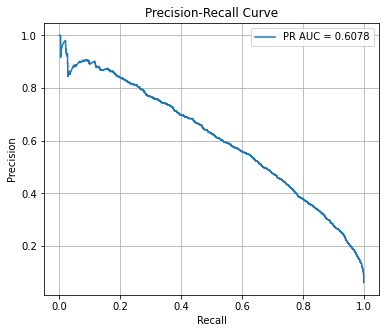

In [179]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

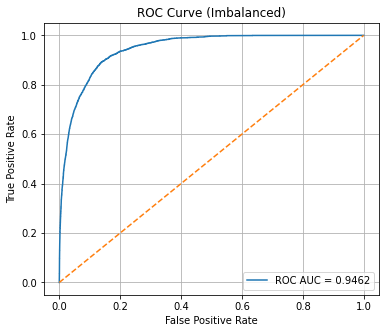

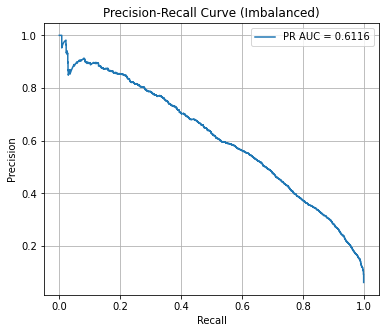

In [180]:
#imbalanced
# ROC Curve
fpr_im, tpr_im, roc_thresholds_im = roc_curve(y_test, y_prob_im)
roc_auc_im = auc(fpr_im, tpr_im)

plt.figure(figsize=(6, 5))
plt.plot(fpr_im, tpr_im, label=f"ROC AUC = {roc_auc_im:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Imbalanced)")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision_im, recall_im, pr_thresholds_im = precision_recall_curve(y_test, y_prob_im)
pr_auc_im = average_precision_score(y_test, y_prob_im)

plt.figure(figsize=(6, 5))
plt.plot(recall_im, precision_im, label=f"PR AUC = {pr_auc_im:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Imbalanced)")
plt.legend()
plt.grid(True)
plt.show()

### Observation
- For imbalanced usually, the Precision-Recall curve is often more informative than ROC because the positive class (>50K) is rare. Here, the difference is negligible in imbalanced vs balanced PR AU is : 0.6116 vs 0.6078

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     37429
           1       0.46      0.74      0.56      2476

    accuracy                           0.93     39905
   macro avg       0.72      0.84      0.76     39905
weighted avg       0.95      0.93      0.94     39905


Confusion Matrix
[[35267  2162]
 [  651  1825]]

ROC AUC: 0.9475138788351504


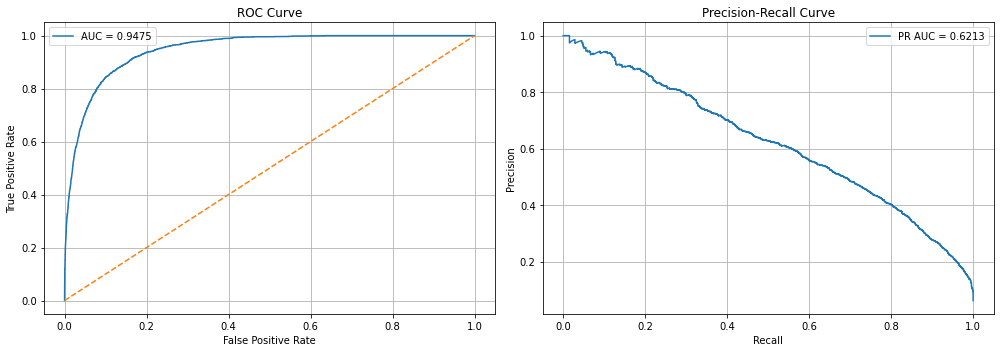

In [ ]:
#BALANCED
from sklearn.ensemble import RandomForestClassifier

continuous_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weight",
    "weeks worked in year",
]

categorical_int_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "own business or self employed",
    "veterans benefits",
]

categorical_obj_cols = [
    col for col in X.select_dtypes(include="object").columns
]

categorical_cols = categorical_int_cols + categorical_obj_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, continuous_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Random Forest Pipeline

rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train

rf_clf.fit(X_train, y_train)

# Predict

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

# Metrics

print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC AUC:", roc_auc)

# ROC + PR Curves

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_curve = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_curve:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(True)

# Precision-Recall Curve
axes[1].plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     37429
           1       0.81      0.36      0.50      2476

    accuracy                           0.96     39905
   macro avg       0.89      0.68      0.74     39905
weighted avg       0.95      0.96      0.95     39905


Confusion Matrix
[[37224   205]
 [ 1586   890]]

ROC AUC: 0.9514857500151822


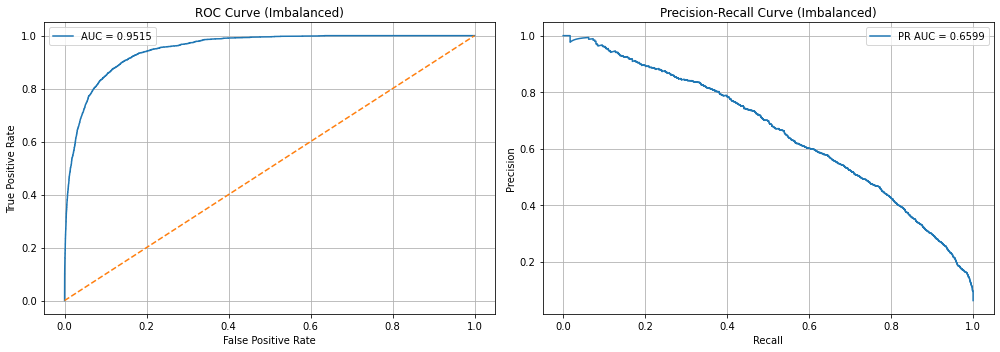

In [ ]:
#IMBALANCED
from sklearn.ensemble import RandomForestClassifier
continuous_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weight",
    "weeks worked in year",
]

categorical_int_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "own business or self employed",
    "veterans benefits",
]

categorical_obj_cols = [
    col for col in X.select_dtypes(include="object").columns
]

categorical_cols = categorical_int_cols + categorical_obj_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, continuous_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Random Forest Pipeline

rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Train

rf_clf.fit(X_train, y_train)

# Predict

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

# Metrics

print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC AUC:", roc_auc)

# ROC + PR Curves

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_curve = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_curve:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (Imbalanced)")
axes[0].legend()
axes[0].grid(True)

# Precision-Recall Curve
axes[1].plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (Imbalanced)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

- Imbalanced model:
    - better when false positives are expensive
    - higher confidence predictions
    - lower minority-class coverage

- Balanced model:
    - better when missing high-income individuals is costly
    - significantly improves minority recall
    - lower precision

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     37429
           1       0.77      0.46      0.57      2476

    accuracy                           0.96     39905
   macro avg       0.87      0.72      0.78     39905
weighted avg       0.95      0.96      0.95     39905


Confusion Matrix
[[37084   345]
 [ 1344  1132]]

ROC AUC: 0.9552503844543407


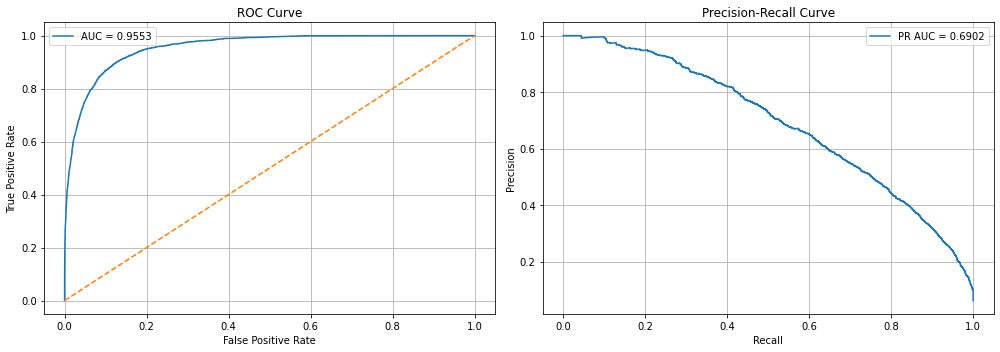

In [187]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

continuous_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weight",
    "weeks worked in year",
]

categorical_int_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "own business or self employed",
    "veterans benefits",
]

categorical_obj_cols = [
    col for col in X.select_dtypes(include="object").columns
]

categorical_cols = categorical_int_cols + categorical_obj_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, continuous_cols),
    ("cat", categorical_transformer, categorical_cols)
])

xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_curve = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_curve:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(True)


# Precision-Recall Curve
axes[1].plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Segmentation Model

In [ ]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Clean target for later profiling only

df = census_df.copy()

df["income_label"] = df["label"]

df["income_binary"] = (df["label"] == "50000+.").astype(int)


# Drop columns 
drop_for_segmentation = [
    "label",
    "income_label",
    "income_binary",
    "weight", 
    "year",   
    "migration prev res in sunbelt",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
]

df_seg = df.drop(columns=drop_for_segmentation, errors="ignore")


# Feature engineering
for col in ["wage per hour", "capital gains", "capital losses", "dividends from stocks"]:
    if col in df_seg.columns:
        df_seg[f"log1p_{col}"] = np.log1p(df_seg[col])

# Binary flags for sparse but informative behaviors
df_seg["has_capital_gains"] = (df_seg["capital gains"] > 0).astype(int)
df_seg["has_capital_losses"] = (df_seg["capital losses"] > 0).astype(int)
df_seg["has_dividends"] = (df_seg["dividends from stocks"] > 0).astype(int)
df_seg["worked_full_year"] = (df_seg["weeks worked in year"] >= 48).astype(int)

# Age buckets for profiling later; not required for clustering input
df_seg["age_bin"] = pd.cut(
    df_seg["age"],
    bins=[0, 18, 25, 35, 50, 65, 100],
    labels=["0-18", "19-25", "26-35", "36-50", "51-65", "65+"],
    include_lowest=True
)

def collapse_rare_categories(series: pd.Series, min_freq: float = 0.01) -> pd.Series:
    freq = series.value_counts(normalize=True, dropna=False)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

high_card_cols = [
    "major industry code",
    "major occupation code",
    "country of birth father",
    "country of birth mother",
    "country of birth self",
    "state of previous residence",
]

for col in high_card_cols:
    if col in df_seg.columns:
        df_seg[col] = collapse_rare_categories(df_seg[col].astype("object"), min_freq=0.01)


# Select features for clustering
numeric_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "num persons worked for employer",
    "weeks worked in year",
    "log1p_wage per hour",
    "log1p_capital gains",
    "log1p_capital losses",
    "log1p_dividends from stocks",
    "has_capital_gains",
    "has_capital_losses",
    "has_dividends",
    "worked_full_year",
]

categorical_cols = [
    "class of worker",
    "education",
    "marital stat",
    "major industry code",
    "major occupation code",
    "race",
    "hispanic origin",
    "sex",
    "member of a labor union",
    "reason for unemployment",
    "full or part time employment stat",
    "tax filer stat",
    "region of previous residence",
    "state of previous residence",
    "detailed household and family stat",
    "detailed household summary in household",
    "family members under 18",
    "citizenship",
    "fill inc questionnaire for veteran's admin",
    "country of birth self",
    "country of birth mother",
    "country of birth father",
]

# Keep only columns that actually exist
numeric_cols = [c for c in numeric_cols if c in df_seg.columns]
categorical_cols = [c for c in categorical_cols if c in df_seg.columns]

X_seg = df_seg[numeric_cols + categorical_cols].copy()


# Preprocessing pipeline for clustering
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

seg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)


# Fit/transform to clustering matrix
X_seg_prepared = seg_preprocessor.fit_transform(X_seg)

print("Raw segmentation shape:", X_seg.shape)
print("Prepared segmentation shape:", X_seg_prepared.shape)

Raw segmentation shape: (199523, 37)
Prepared segmentation shape: (199523, 197)


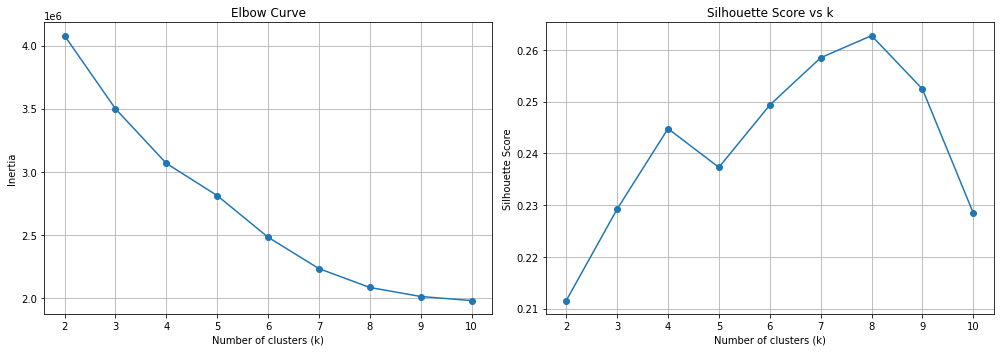

cluster
0      7379
1    101971
2     86267
3      3906
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Elbow + silhouette over a range of K
k_values = range(2, 11)

inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_seg_prepared)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg_prepared, cluster_labels))


# Plot elbow and silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

axes[1].plot(list(k_values), sil_scores, marker="o")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Fit final KMeans model
best_k = 4   

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_seg["cluster"] = kmeans.fit_predict(X_seg_prepared)

print(df_seg["cluster"].value_counts().sort_index())

- lower inertia means, tighter clusters and poitns are closer to cluster centers
- In general the bend is the optimal best point, here so far, I do not seea clear elbow point so considering 4 and 8 for profiling based evaluation. 
- till k = 4, shows sharp improvement but slower afterwards. 
- Shilhouette score from k=4 to 8 is not very high, from .24 to .27 approx so k = 4 is fine. 

In [193]:
df_seg.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,log1p_capital gains,log1p_capital losses,log1p_dividends from stocks,has_capital_gains,has_capital_losses,has_dividends,worked_full_year,age_bin,cluster,income_binary
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,0.0,0.0,0.0,0,0,0,0,65+,1,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,0.0,0.0,0.0,0,0,0,1,51-65,2,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,0.0,0.0,0.0,0,0,0,0,0-18,1,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,0.0,0.0,0.0,0,0,0,0,0-18,1,0
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,0.0,0.0,0.0,0,0,0,0,0-18,1,0


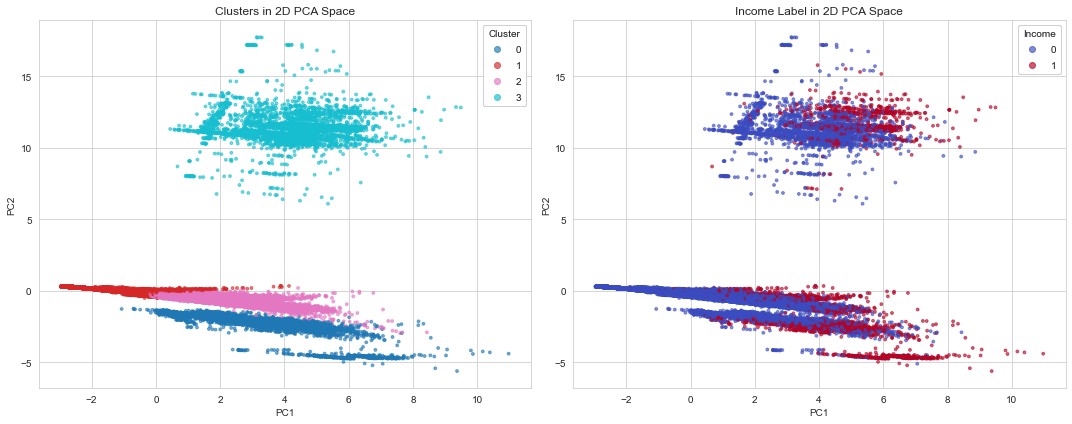

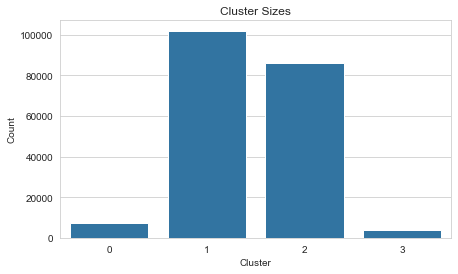

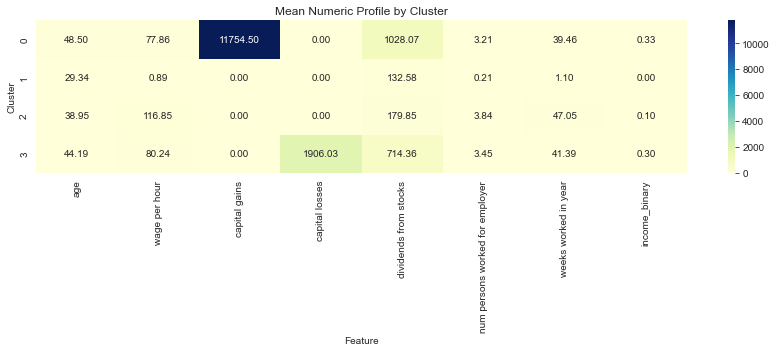

In [ ]:

# PCA visualization of clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg_prepared)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_seg["cluster"].values,
    "income_binary": df_seg["income_binary"].values
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(
    pca_df["PC1"], pca_df["PC2"],
    c=pca_df["cluster"], cmap="tab10", s=8, alpha=0.6
)
axes[0].set_title("Clusters in 2D PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
legend1 = axes[0].legend(*scatter.legend_elements(), title="Cluster", loc="best")
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(
    pca_df["PC1"], pca_df["PC2"],
    c=pca_df["income_binary"], cmap="coolwarm", s=8, alpha=0.6
)
axes[1].set_title("Income Label in 2D PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Income", loc="best")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

# Cluster size plot
plt.figure(figsize=(7, 4))
sns.countplot(data=df_seg, x="cluster", order=sorted(df_seg["cluster"].unique()))
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

# Cluster profiling: numeric features
profile_numeric_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "num persons worked for employer",
    "weeks worked in year",
    "income_binary"
]

cluster_profile = df_seg.groupby("cluster")[profile_numeric_cols].mean()

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Mean Numeric Profile by Cluster")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


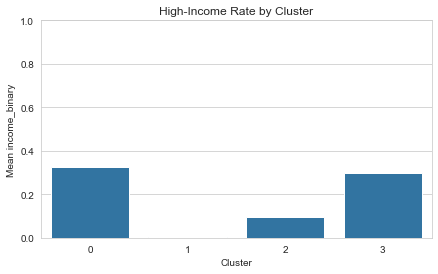


=== education by cluster ===


education,10th grade,11th grade,12th grade no diploma,1st 2nd 3rd or 4th grade,5th or 6th grade,7th and 8th grade,9th grade,Associates degree-academic program,Associates degree-occup /vocational,Bachelors degree(BA AB BS),Children,Doctorate degree(PhD EdD),High school graduate,Less than 1st grade,Masters degree(MA MS MEng MEd MSW MBA),Prof school degree (MD DDS DVM LLB JD),Some college but no degree
cluster,,,,,,,,,,,,,,,,,
0,0.022767,0.020328,0.007183,0.003930,0.008673,0.028324,0.015178,0.029679,0.038623,0.219406,0.000000,0.026291,0.270091,0.000813,0.089443,0.044315,0.174956
1,0.048337,0.036991,0.010807,0.011258,0.019113,0.059115,0.044483,0.008022,0.010630,0.034049,0.465054,0.001628,0.157986,0.005894,0.009552,0.002059,0.075021
2,0.027206,0.032967,0.010920,0.006978,0.014212,0.019393,0.017643,0.037001,0.044513,0.161835,0.000000,0.009389,0.339690,0.002411,0.052581,0.012890,0.210370
3,0.028930,0.028162,0.007424,0.005120,0.009729,0.024834,0.015361,0.034306,0.038146,0.208141,0.000000,0.023810,0.256016,0.001024,0.094982,0.036866,0.187148



=== marital stat by cluster ===


marital stat,Divorced,Married-A F spouse present,Married-civilian spouse present,Married-spouse absent,Never married,Separated,Widowed
cluster,,,,,,,
0,0.097439,0.001220,0.643312,0.008673,0.152731,0.019515,0.077111
1,0.031970,0.002354,0.238391,0.005403,0.630964,0.012278,0.078640
2,0.096352,0.004787,0.612969,0.010097,0.233264,0.023137,0.019393
3,0.107271,0.000768,0.585509,0.008193,0.229135,0.017409,0.051715



=== class of worker by cluster ===


class of worker,Federal government,Local government,Never worked,Not in universe,Private,Self-employed-incorporated,Self-employed-not incorporated,State government,Without pay
cluster,,,,,,,,,
0,0.033202,0.059087,0.000000,0.221033,0.521480,0.056105,0.076975,0.031983,0.000136
1,0.000824,0.002618,0.004246,0.936570,0.045444,0.001069,0.007218,0.001579,0.000431
2,0.028678,0.079312,0.000070,0.028261,0.710886,0.029501,0.079161,0.042774,0.001356
3,0.031234,0.061188,0.000000,0.172299,0.568356,0.050435,0.079877,0.035842,0.000768



=== major occupation code by cluster ===


major occupation code,Adm support including clerical,Executive admin and managerial,Farming forestry and fishing,Handlers equip cleaners etc,Machine operators assmblrs & inspctrs,Not in universe,Other,Other service,Precision production craft & repair,Professional specialty,Sales,Technicians and related support,Transportation and material moving
cluster,,,,,,,,,,,,,
0,0.067218,0.167096,0.023038,0.018431,0.034829,0.221033,0.018973,0.041605,0.089579,0.164114,0.100420,0.024665,0.029001
1,0.007188,0.001873,0.004315,0.005521,0.003560,0.940817,0.003001,0.015308,0.004335,0.003530,0.008218,0.000755,0.001579
2,0.154242,0.121217,0.028389,0.038520,0.064845,0.028331,0.022546,0.116360,0.104860,0.135915,0.113647,0.030545,0.040583
3,0.077317,0.157194,0.022273,0.026882,0.042243,0.172299,0.022017,0.049411,0.094470,0.164875,0.102407,0.031746,0.036866



=== sex by cluster ===


sex,Female,Male
cluster,,
0,0.279577,0.720423
1,0.572084,0.427916
2,0.492448,0.507552
3,0.282386,0.717614


In [ ]:
# Recreate income_binary in df_seg
# Use the original label column from census_df or df if df_seg no longer has it
df_seg["income_binary"] = census_df.loc[df_seg.index, "label"].astype(int)
# 6) Cluster-wise high-income rate
income_by_cluster = df_seg.groupby("cluster")["income_binary"].mean().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=income_by_cluster.index, y=income_by_cluster.values)
plt.title("High-Income Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean income_binary")
plt.ylim(0, 1)
plt.show()

# Categorical profile by cluster
for col in ["education", "marital stat", "class of worker", "major occupation code", "sex"]:
    print(f"\n=== {col} by cluster ===")
    display(pd.crosstab(df_seg["cluster"], df_seg[col], normalize="index"))

### Optimal Cluster k = 8

cluster
0    41392
1    55653
2     6945
3    16846
4    10541
5     3901
6    63853
7      392
Name: count, dtype: int64


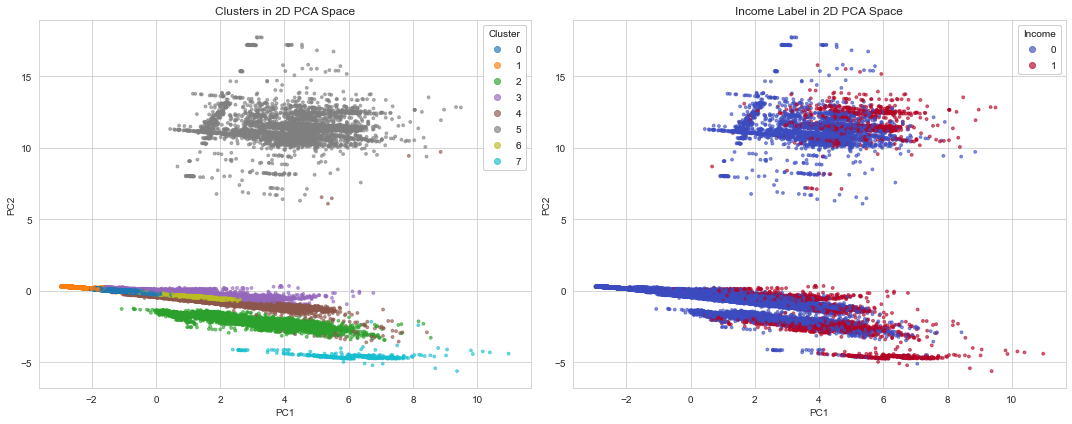

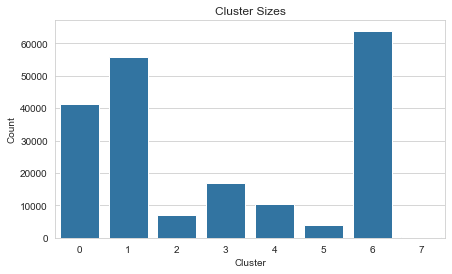

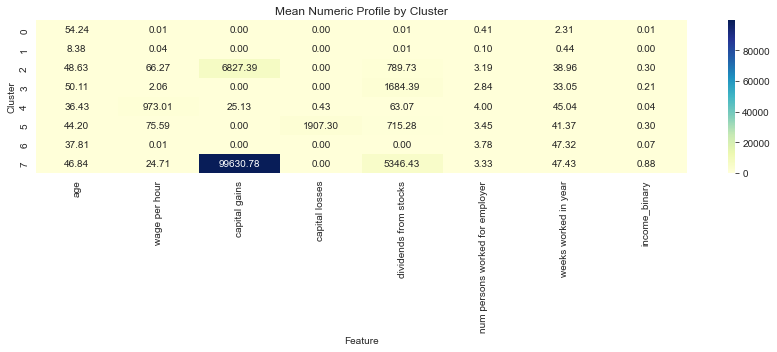

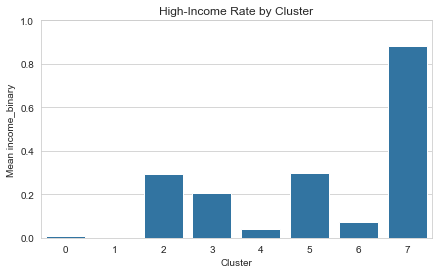


=== education by cluster ===


education,10th grade,11th grade,12th grade no diploma,1st 2nd 3rd or 4th grade,5th or 6th grade,7th and 8th grade,9th grade,Associates degree-academic program,Associates degree-occup /vocational,Bachelors degree(BA AB BS),Children,Doctorate degree(PhD EdD),High school graduate,Less than 1st grade,Masters degree(MA MS MEng MEd MSW MBA),Prof school degree (MD DDS DVM LLB JD),Some college but no degree
cluster,,,,,,,,,,,,,,,,,
0,0.063684,0.056412,0.018434,0.027783,0.046144,0.104320,0.048125,0.015897,0.022251,0.061485,0.000048,0.002875,0.347048,0.013795,0.017636,0.003672,0.150391
1,0.037428,0.021724,0.004762,0.000180,0.000755,0.028103,0.043214,0.000144,0.000252,0.000629,0.852065,0.000000,0.003522,0.000395,0.000054,0.000000,0.006774
2,0.024046,0.021598,0.007631,0.004176,0.009215,0.030094,0.015983,0.030814,0.039453,0.213535,0.000000,0.023614,0.278186,0.000864,0.086825,0.033837,0.180130
3,0.014306,0.012585,0.004333,0.001425,0.002790,0.013653,0.007895,0.040722,0.037813,0.265286,0.000000,0.020539,0.259765,0.000356,0.106969,0.028968,0.182595
4,0.042216,0.049616,0.012902,0.005502,0.010910,0.020207,0.026278,0.035575,0.048477,0.094583,0.000000,0.001423,0.395029,0.002372,0.017456,0.002941,0.234513
5,0.028711,0.028198,0.007434,0.005127,0.009741,0.024865,0.015381,0.034350,0.037939,0.208408,0.000000,0.023840,0.255575,0.001025,0.095104,0.036914,0.187388
6,0.029317,0.036600,0.012638,0.007956,0.016616,0.021549,0.019608,0.035785,0.044508,0.147229,0.000000,0.007768,0.349709,0.002897,0.043725,0.010195,0.213898
7,0.002551,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007653,0.028061,0.311224,0.000000,0.076531,0.119898,0.000000,0.142857,0.234694,0.076531



=== marital stat by cluster ===


marital stat,Divorced,Married-A F spouse present,Married-civilian spouse present,Married-spouse absent,Never married,Separated,Widowed
cluster,,,,,,,
0,0.077310,0.005363,0.523821,0.012829,0.175420,0.030175,0.175082
1,0.000216,0.000000,0.000090,0.000090,0.999299,0.000270,0.000036
2,0.098344,0.001008,0.632253,0.008927,0.158531,0.019870,0.081066
3,0.060667,0.005402,0.741660,0.005817,0.113439,0.007064,0.065950
4,0.094868,0.005597,0.531069,0.008823,0.311545,0.027322,0.020776
5,0.106896,0.000769,0.586260,0.008203,0.228659,0.017431,0.051782
6,0.099463,0.004401,0.586253,0.010884,0.256824,0.024713,0.017462
7,0.063776,0.005102,0.844388,0.005102,0.058673,0.012755,0.010204



=== class of worker by cluster ===


class of worker,Federal government,Local government,Never worked,Not in universe,Private,Self-employed-incorporated,Self-employed-not incorporated,State government,Without pay
cluster,,,,,,,,,
0,0.001739,0.004928,0.003431,0.888118,0.074072,0.002633,0.021357,0.002923,0.000797
1,0.000162,0.000970,0.005193,0.969615,0.021472,0.000413,0.001545,0.000395,0.000234
2,0.033693,0.061339,0.000000,0.229662,0.520662,0.047948,0.074154,0.032397,0.000144
3,0.021429,0.057580,0.000059,0.332839,0.435712,0.045115,0.074142,0.032352,0.000772
4,0.031211,0.070107,0.000000,0.000000,0.861873,0.000000,0.000000,0.036809,0.000000
5,0.030761,0.061266,0.000000,0.172520,0.568316,0.050500,0.079979,0.035888,0.000769
6,0.028096,0.080576,0.000110,0.025230,0.709583,0.027595,0.083724,0.043491,0.001597
7,0.015306,0.017857,0.000000,0.091837,0.510204,0.206633,0.135204,0.022959,0.000000



=== major occupation code by cluster ===


major occupation code,Adm support including clerical,Executive admin and managerial,Farming forestry and fishing,Handlers equip cleaners etc,Machine operators assmblrs & inspctrs,Not in universe,Other,Other service,Precision production craft & repair,Professional specialty,Sales,Technicians and related support,Transportation and material moving
cluster,,,,,,,,,,,,,
0,0.014375,0.005822,0.007924,0.007417,0.007731,0.891549,0.005218,0.023531,0.010968,0.007731,0.012635,0.001546,0.003551
1,0.001959,0.000072,0.002012,0.003342,0.000539,0.974808,0.001689,0.008984,0.000593,0.000952,0.004618,0.000072,0.000359
2,0.069834,0.159395,0.023902,0.019150,0.036429,0.229662,0.019294,0.042909,0.090857,0.153492,0.098920,0.025486,0.030670
3,0.097056,0.151609,0.013772,0.008607,0.017274,0.332898,0.008548,0.027366,0.048439,0.171079,0.089042,0.022439,0.011872
4,0.188028,0.052936,0.015558,0.059197,0.101414,0.000000,0.025140,0.162508,0.123802,0.081871,0.104734,0.038991,0.045821
5,0.076903,0.157139,0.022302,0.026916,0.042297,0.172520,0.022046,0.049218,0.094335,0.165086,0.102538,0.031787,0.036914
6,0.152256,0.114278,0.032152,0.041094,0.066528,0.025339,0.024024,0.124552,0.108029,0.124912,0.113667,0.029129,0.044039
7,0.022959,0.308673,0.010204,0.007653,0.007653,0.091837,0.010204,0.020408,0.033163,0.346939,0.137755,0.000000,0.002551



=== sex by cluster ===


sex,Female,Male
cluster,,
0,0.679721,0.320279
1,0.489318,0.510682
2,0.283945,0.716055
3,0.531046,0.468954
4,0.530595,0.469405
5,0.282748,0.717252
6,0.484316,0.515684
7,0.198980,0.801020


In [ ]:
# Fit final KMeans model
best_k = 8   # change after inspecting plots

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_seg["cluster"] = kmeans.fit_predict(X_seg_prepared)

print(df_seg["cluster"].value_counts().sort_index())


# PCA visualization of clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg_prepared)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_seg["cluster"].values,
    "income_binary": df_seg["income_binary"].values
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(
    pca_df["PC1"], pca_df["PC2"],
    c=pca_df["cluster"], cmap="tab10", s=8, alpha=0.6
)
axes[0].set_title("Clusters in 2D PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
legend1 = axes[0].legend(*scatter.legend_elements(), title="Cluster", loc="best")
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(
    pca_df["PC1"], pca_df["PC2"],
    c=pca_df["income_binary"], cmap="coolwarm", s=8, alpha=0.6
)
axes[1].set_title("Income Label in 2D PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Income", loc="best")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

# Cluster size plot

plt.figure(figsize=(7, 4))
sns.countplot(data=df_seg, x="cluster", order=sorted(df_seg["cluster"].unique()))
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

#Cluster profiling: numeric features
profile_numeric_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "num persons worked for employer",
    "weeks worked in year",
    "income_binary"
]

cluster_profile = df_seg.groupby("cluster")[profile_numeric_cols].mean()

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Mean Numeric Profile by Cluster")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()
# Recreate income_binary in df_seg
# Use the original label column from census_df or df if df_seg no longer has it
df_seg["income_binary"] = census_df.loc[df_seg.index, "label"].astype(int)
# 6) Cluster-wise high-income rate
income_by_cluster = df_seg.groupby("cluster")["income_binary"].mean().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=income_by_cluster.index, y=income_by_cluster.values)
plt.title("High-Income Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean income_binary")
plt.ylim(0, 1)
plt.show()

# 7) Categorical profile by cluster
for col in ["education", "marital stat", "class of worker", "major occupation code", "sex"]:
    print(f"\n=== {col} by cluster ===")
    display(pd.crosstab(df_seg["cluster"], df_seg[col], normalize="index"))

## Initial Data Exploration 
- Below cells are initial exploration of data. 
- Observations:
    - Continuous numeric attributes (age, capital gains, wage per hour etc.)
    - Categorical attributes (sex, race, marital stat etc.)
    - Integer-coded categorical attributes (detailed occupation recode, veteran benefits etc.)
    - Some highly skews attributes (capital gains, capital losses etc.)
    - Migration related attributes which are dominated by “Not in universe”


In [21]:
census_df.isnull().sum()

age                                               0
class of worker                                   0
detailed industry recode                          0
detailed occupation recode                        0
education                                         0
wage per hour                                     0
enroll in edu inst last wk                        0
marital stat                                      0
major industry code                               0
major occupation code                             0
race                                              0
hispanic origin                                 874
sex                                               0
member of a labor union                           0
reason for unemployment                           0
full or part time employment stat                 0
capital gains                                     0
capital losses                                    0
dividends from stocks                             0
tax filer st

In [22]:
census_df.head(3)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label,cluster
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.,1
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.,0


In [89]:
census_df['cluster'].value_counts()

cluster
2    52774
1    50028
3    49993
0    46728
Name: count, dtype: int64

<ipython-input-30-f8716c3113f7>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-30-f8716c3113f7>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(census_df[x], bins=20)
<ipython-input-30-f8716c3113f7>:9: UserWarning: 

`distplot` is a deprecated function an

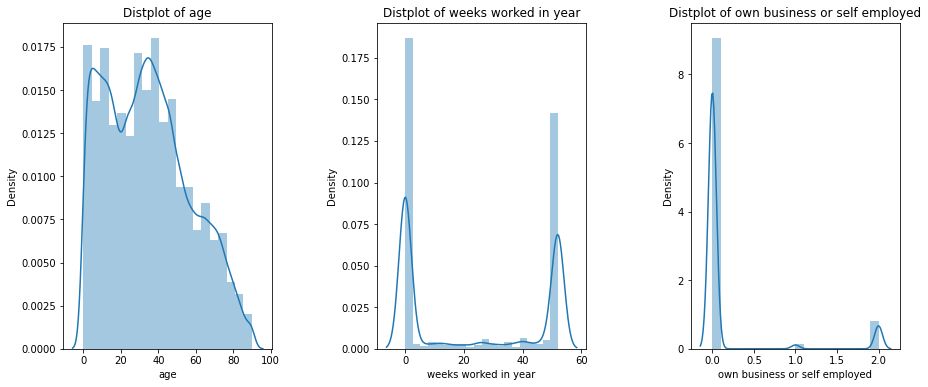

In [30]:
import seaborn as sns 

plt.figure(1,figsize=(15,6))
n=0
for x in ['age', 'weeks worked in year', 'own business or self employed']:
    n += 1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(census_df[x], bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

In [30]:
age_0_18 = census_df.age[(census_df.age >= 0) & (census_df.age <= 18)]
age_19_36 = census_df.age[(census_df.age >= 19) & (census_df.age <= 36)]
age_37_50 = census_df.age[(census_df.age >= 38) & (census_df.age <= 50)]
age_51_71 = census_df.age[(census_df.age >= 51) & (census_df.age <= 71)]
age_72_92 = census_df.age[(census_df.age >= 72) & (census_df.age <= 92)]

<ipython-input-31-f9e856907042>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_x, y=age_y, palette='mako')


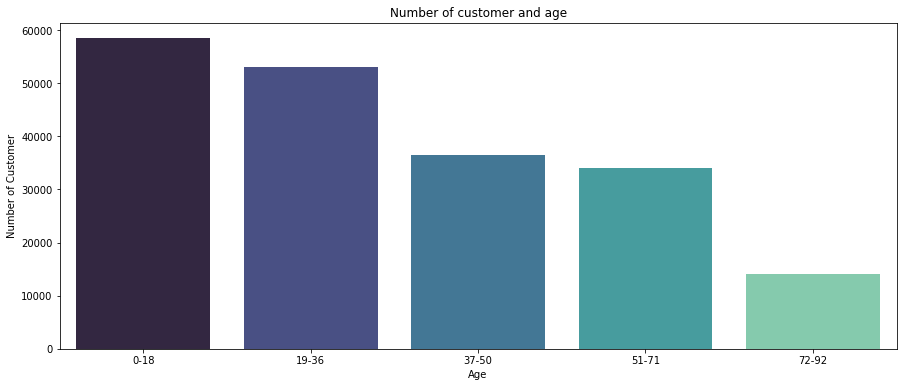

In [31]:
age_x = ["0-18", "19-36", "37-50", "51-71", "72-92"]
age_y = [len(age_0_18.values),len(age_19_36.values),len(age_37_50.values), len(age_51_71.values), len(age_72_92.values)]

plt.figure(figsize=(15,6))
sns.barplot(x=age_x, y=age_y, palette='mako')
plt.title("Number of customer and age")
plt.xlabel("Age")
plt.ylabel("Number of Customer")
plt.show()

<Axes: xlabel='label', ylabel='age'>

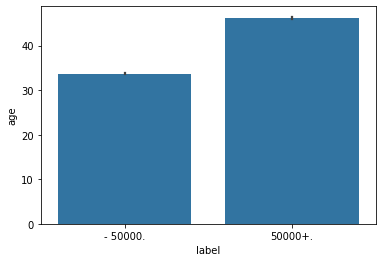

In [37]:
sns.barplot(x='label', y='age', data=census_df)

<Axes: xlabel='capital gains', ylabel='Count'>

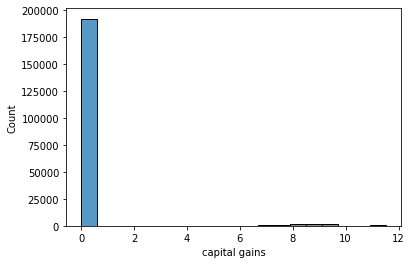

In [40]:
import numpy as np
sns.histplot(np.log1p(census_df['capital gains']))

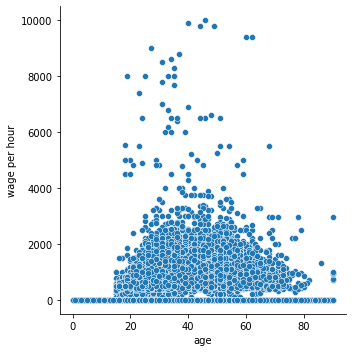

In [38]:
sns.relplot(x='age', y='wage per hour', data=census_df)

In [74]:
for x in census_df.columns:
    print("x", x)
    print(census_df[x].value_counts())
    print("_______")

x age
age
34    3489
35    3450
36    3353
31    3351
33    3340
      ... 
85     423
86     348
87     301
88     241
89     195
Name: count, Length: 91, dtype: int64
_______
x class of worker
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64
_______
x detailed industry recode
detailed industry recode
0     100684
33     17070
43      8283
4       5984
42      4683
45      4482
29      4209
37      4022
41      3964
32      3596
35      3380
39      2937
34      2765
44      2549
2       2196
11      1764
50      1704
40      1651
47      1644
38      1629
24      1503
12      1350
19      1346
30      1181
31      1178
25      1

In [73]:
for x in census_df.columns:
    print("x", x)
    print(census_df[x].unique())
    print("_______")

x age
[73 58 18  9 10 48 42 28 47 34  8 32 51 46 26 13 39 16 35 12 27 56 55  2
  1 37  4 63 25 81 11 30  7 66 84 52  5 36 72 61 41 90 49  6  0 33 57 50
 24 17 53 40 54 22 29 85 38 76 21 31 74 19 15  3 43 68 71 45 62 23 69 75
 44 59 60 64 65 70 67 78 20 14 83 86 89 77 79 82 80 87 88]
_______
x class of worker
['Not in universe' 'Self-employed-not incorporated' 'Private'
 'Local government' 'Federal government' 'Self-employed-incorporated'
 'State government' 'Never worked' 'Without pay']
_______
x detailed industry recode
[ 0  4 40 34 43 37 24 39 12 35 45  3 19 29 32 48 33 23 44 36 31 30 41  5
 11  9 42  6 18 50  2  1 26 47 16 14 22 17  7  8 25 46 27 15 13 49 38 21
 28 20 51 10]
_______
x detailed occupation recode
[ 0 34 10  3 40 26 37 31 12 36 41 22  2 35 25 23 42  8 19 29 27 16 33 13
 18  9 17 39 32 11 30 38 20  7 21 44 24 43 28  4  1  6 45 14  5 15 46]
_______
x education
['High school graduate' 'Some college but no degree' '10th grade'
 'Children' 'Bachelors degree(BA AB BS)'
 'Mas

In [54]:
census_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 43 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199523 non-null  object 
 

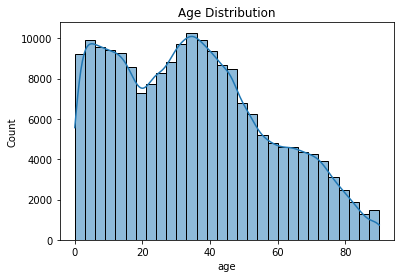

In [76]:
sns.histplot(census_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

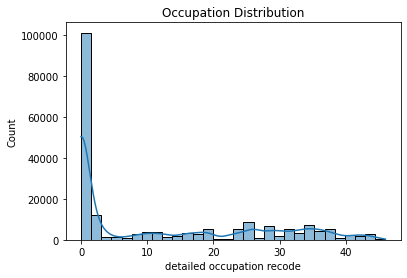

In [79]:
sns.histplot(census_df['detailed occupation recode'], bins=30, kde=True)
plt.title("Occupation Distribution")
plt.show()

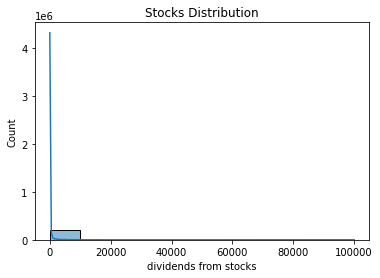

In [81]:
sns.histplot(census_df['dividends from stocks'], bins=10, kde=True)
plt.title("Stocks Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

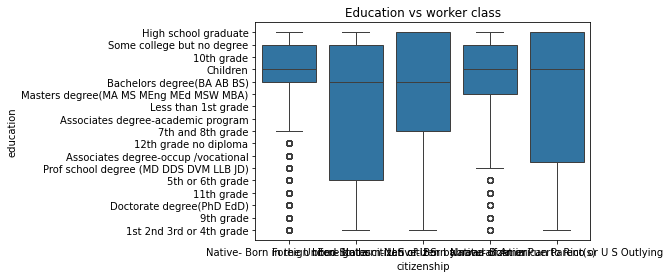

In [ ]:
sns.boxplot(x="citizenship", y="education", data = census_df)
plt.xticks()
plt.title("Education vs citizenship")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

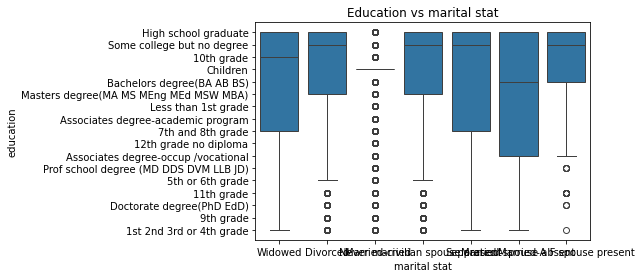

In [85]:
sns.boxplot(x="marital stat", y="education", data = census_df)
plt.xticks()
plt.title("Education vs marital stat")
plt.show

In [42]:
corr = census_df[["capital gains","capital losses","age","wage per hour","num persons worked for employer", "weight"]].corr()

In [43]:
corr

,capital gains,capital losses,age,wage per hour,num persons worked for employer,weight
capital gains,1.000000,-0.012700,0.053590,-0.001082,0.058015,0.002549
capital losses,-0.012700,1.000000,0.063351,0.010993,0.084255,0.008052
age,0.053590,0.063351,1.000000,0.036938,0.140887,-0.001611
wage per hour,-0.001082,0.010993,0.036938,1.000000,0.191543,0.012353
num persons worked for employer,0.058015,0.084255,0.140887,0.191543,1.000000,0.042778
weight,0.002549,0.008052,-0.001611,0.012353,0.042778,1.000000


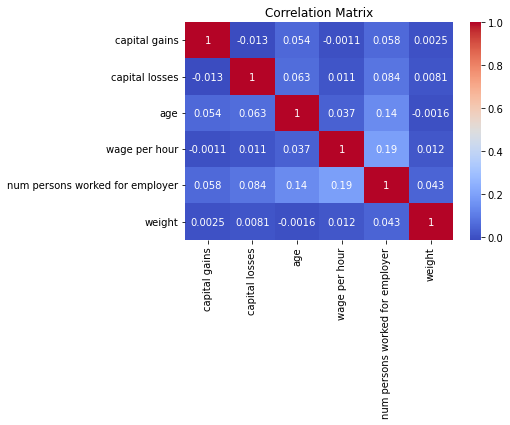

In [44]:
sns.heatmap(corr,annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()